# R Programming – NPTEL Week 11: Complete Implementation

This notebook implements the functions and examples covered in the uploaded NPTEL Week 11 notes.

**Topics covered**
1. Data frames: `summary()`, `attach()`, `detach()`, `subset()`, indexing, `split()`, `is.data.frame()`
2. Importing Excel and other data files
3. Writing/saving data: `write()`, `write.csv()`, `write.table()`
4. Absolute and relative frequencies using `table()`
5. Partition values using `quantile()`
6. Graphics: scatter plots and bar plots
7. Bar-plot customization: colours, title, legend, subtitle, axis labels

The examples follow the terminology and examples presented in the supplied NPTEL notes.


## 1. Setup

In [1]:
# Install/load packages needed for the notebook
packages <- c("MASS", "readxl", "foreign")

for (p in packages) {
  if (!requireNamespace(p, quietly = TRUE)) {
    install.packages(p, repos = "https://cloud.r-project.org")
  }
}

library(MASS)
library(readxl)
library(foreign)

cat("Setup complete.\n")


Setup complete.


## 2. Data Frames – `painters`

The notes use the `painters` data frame from the **MASS** package and demonstrate operations on its columns and rows. fileciteturn0file0L11-L26

In [2]:
# Load the painters data frame
data("painters", package = "MASS")

painters
str(painters)
head(painters)


,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<fct>
Da Udine,10,8,16,3,A
Da Vinci,15,16,4,14,A
Del Piombo,8,13,16,7,A
Del Sarto,12,16,9,8,A
Fr. Penni,0,15,8,0,A
Guilio Romano,15,16,4,14,A
Michelangelo,8,17,4,8,A
Perino del Vaga,15,16,7,6,A
Perugino,4,12,10,4,A


'data.frame':	54 obs. of  5 variables:
 $ Composition: int  10 15 8 12 0 15 8 15 4 17 ...
 $ Drawing    : int  8 16 13 16 15 16 17 16 12 18 ...
 $ Colour     : int  16 4 16 9 8 4 4 7 10 12 ...
 $ Expression : int  3 14 7 8 0 14 8 6 4 18 ...
 $ School     : Factor w/ 8 levels "A","B","C","D",..: 1 1 1 1 1 1 1 1 1 1 ...


,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<fct>
Da Udine,10,8,16,3,A
Da Vinci,15,16,4,14,A
Del Piombo,8,13,16,7,A
Del Sarto,12,16,9,8,A
Fr. Penni,0,15,8,0,A
Guilio Romano,15,16,4,14,A


### 2.1 `summary()` on a categorical variable

In [3]:
# Frequency summary of the School categorical variable
summary(painters$School)


A  B  C  D  E  F  G  H 
10  6  6 10  7  4  7  4

### 2.2 `attach()` and `detach()`

The notes demonstrate that `attach()` permits direct access to data-frame variables, while `detach()` restores the need for the data-frame prefix. fileciteturn0file0L45-L57 fileciteturn0file0L71-L76

In [4]:
# Attach the data frame
attach(painters)

# Variables can now be referenced directly
summary(School)
summary(Composition)

# Always detach after demonstration to avoid name conflicts
detach(painters)


A  B  C  D  E  F  G  H 
10  6  6 10  7  4  7  4

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    8.25   12.50   11.56   15.00   18.00 

### 2.3 Selecting subsets with `subset()`

In [5]:
# Select painters belonging to School F
subset_F <- subset(painters, School == "F")
subset_F

# Select observations with Composition <= 6
subset_composition <- subset(painters, Composition <= 6)
subset_composition


,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<fct>
Durer,8,10,10,8,F
Holbein,9,10,16,13,F
Pourbus,4,15,6,6,F
Van Leyden,8,6,6,4,F


,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<fct>
Fr. Penni,0,15,8,0,A
Perugino,4,12,10,4,A
Bassano,6,8,17,0,D
Bellini,4,6,14,0,D
Murillo,6,8,15,4,D
Palma Vecchio,5,6,16,0,D
Caravaggio,6,6,16,0,E
Pourbus,4,15,6,6,F


### 2.4 Equivalent row indexing

In [6]:
# Equivalent way to select School F
painters[painters[["School"]] == "F", ]


,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<fct>
Durer,8,10,10,8,F
Holbein,9,10,16,13,F
Pourbus,4,15,6,6,F
Van Leyden,8,6,6,4,F


### 2.5 Selecting columns with `select=`

The notes show that unwanted columns can be removed using negative column indices. fileciteturn0file0L163-L170

In [7]:
# School F, excluding Colour (column 3) and School (column 5)
subset(painters, School == "F", select = c(-3, -5))


,Composition,Drawing,Expression
,<int>,<int>,<int>
Durer,8,10,8
Holbein,9,10,13
Pourbus,4,15,6
Van Leyden,8,6,4


### 2.6 `split()`

In [8]:
# Split painters by School
splitted <- split(painters, painters$School)

# Display the split data frames
splitted

# Check that one component is itself a data frame
is.data.frame(splitted$A)


,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<fct>
Da Udine,10,8,16,3,A
Da Vinci,15,16,4,14,A
Del Piombo,8,13,16,7,A
Del Sarto,12,16,9,8,A
Fr. Penni,0,15,8,0,A
Guilio Romano,15,16,4,14,A
Michelangelo,8,17,4,8,A
Perino del Vaga,15,16,7,6,A
Perugino,4,12,10,4,A


[1] TRUE

## 3. Importing Excel and Other Data Files

The notes use `readxl::read_excel()` for Excel files, including selecting sheets, limiting rows with `n_max`, and selecting an Excel range. fileciteturn0file0L298-L315 fileciteturn0file0L395-L402

In [9]:
# Create a small Excel workbook inside Colab so the examples are runnable
# without requiring an external file.

if (!requireNamespace("writexl", quietly = TRUE)) {
  install.packages("writexl", repos = "https://cloud.r-project.org")
}
library(writexl)

sheet1 <- data.frame(
  `Variable 1` = 1:5,
  `Variable 2` = c(10, 20, 30, 40, 50),
  `Variable 3` = c(100, 200, 300, 400, 500)
)

sheet2 <- data.frame(
  `Variable 4` = 6:10,
  `Variable 5` = c(110, 120, 130, 140, 150),
  `Variable 6` = c(110, 210, 310, 410, 510)
)

excel_file <- file.path(tempdir(), "spexcel.xlsx")
write_xlsx(list(Sheet1 = sheet1, Sheet2 = sheet2), excel_file)

excel_file


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "/tmp/RtmpuWAYdr/spexcel.xlsx"

In [10]:
# Read the first sheet
dataspexcel <- read_excel(excel_file, sheet = 1)
dataspexcel

# Extract columns and calculate a mean
dataspexcel$`Variable 1`
dataspexcel$`Variable 2`
mean(dataspexcel$`Variable 1`)


Variable.1,Variable.2,Variable.3
<dbl>,<dbl>,<dbl>
1,10,100
2,20,200
3,30,300
4,40,400
5,50,500


Warning message:
“Unknown or uninitialised column: `Variable 1`.”


NULL

Warning message:
“Unknown or uninitialised column: `Variable 2`.”


NULL

Warning message:
“Unknown or uninitialised column: `Variable 1`.”
Warning message in mean.default(dataspexcel$`Variable 1`):
“argument is not numeric or logical: returning NA”


[1] NA

In [11]:
# Read the second sheet
dataspexcel2 <- read_excel(excel_file, sheet = 2)
dataspexcel2

dataspexcel2$`Variable 4`
dataspexcel2$`Variable 5`
dataspexcel2$`Variable 6`
mean(dataspexcel2$`Variable 6`)


Variable.4,Variable.5,Variable.6
<dbl>,<dbl>,<dbl>
6,110,110
7,120,210
8,130,310
9,140,410
10,150,510


Warning message:
“Unknown or uninitialised column: `Variable 4`.”


NULL

Warning message:
“Unknown or uninitialised column: `Variable 5`.”


NULL

Warning message:
“Unknown or uninitialised column: `Variable 6`.”


NULL

Warning message:
“Unknown or uninitialised column: `Variable 6`.”
Warning message in mean.default(dataspexcel2$`Variable 6`):
“argument is not numeric or logical: returning NA”


[1] NA

In [12]:
# Limit the number of rows read
dataspexcel4 <- read_excel(excel_file, n_max = 3)
dataspexcel4

# Read an Excel range using A1 notation
read_excel(excel_file, range = "A1:C4")

# R1C1 notation is also supported by readxl
# Example from the notes:
# read_excel(excel_file, range = "R1C2:R2C5")


Variable.1,Variable.2,Variable.3
<dbl>,<dbl>,<dbl>
1,10,100
2,20,200
3,30,300


Variable.1,Variable.2,Variable.3
<dbl>,<dbl>,<dbl>
1,10,100
2,20,200
3,30,300


### 3.1 Other file formats

The notes also introduce `foreign::read.spss()` for SPSS files and `XML::readHTMLTable()` for HTML tables, plus functions for Octave/MATLAB, SYSTAT, SAS XPORT and Stata files. These require actual source files to demonstrate end-to-end reading. fileciteturn0file0L435-L464

In [13]:
# Examples of the functions from the notes.
# Uncomment and provide a real file path when you have the corresponding file.

# SPSS:
# data_spss <- read.spss("datafile.sav")

# HTML table (requires XML package):
# install.packages("XML")
# library(XML)
# data_html <- readHTMLTable("filename")

# Other formats from foreign:
# read.octave("file")   # Octave/MATLAB
# read.systat("file")   # SYSTAT
# read.xport("file")    # SAS XPORT
# read.dta("file")      # Stata


## 4. Saving and Writing Data Files

The notes cover `write()`, `write.csv()`, and `write.table()`, including separators, appending, and row/column names. fileciteturn0file0L490-L506 fileciteturn0file0L529-L546

In [14]:
# Create a vector as in the notes
x <- 1:100
head(x)
tail(x)

# Write vector data to a text file
write_file <- file.path(tempdir(), "shalabh.txt")
write(x, file = write_file)

cat("First few lines of written file:\n")
cat(readLines(write_file, n = 5), sep = "\n")


[1] 1 2 3 4 5 6

[1]  95  96  97  98  99 100

First few lines of written file:
1 2 3 4 5
6 7 8 9 10
11 12 13 14 15
16 17 18 19 20
21 22 23 24 25


In [15]:
# Write a data frame to CSV
csv_file <- file.path(tempdir(), "painters_subset.csv")
write.csv(subset_F, file = csv_file, row.names = TRUE)

# Read it back
read.csv(csv_file)


X,Composition,Drawing,Colour,Expression,School
<chr>,<int>,<int>,<int>,<int>,<lgl>
Durer,8,10,10,8,FALSE
Holbein,9,10,16,13,FALSE
Pourbus,4,15,6,6,FALSE
Van Leyden,8,6,6,4,FALSE


In [16]:
# Write a table using write.table()
table_file <- file.path(tempdir(), "painters_subset.tsv")
write.table(
  subset_F,
  file = table_file,
  sep = "\t",
  row.names = TRUE,
  col.names = TRUE,
  quote = TRUE
)

# Read it back
read.delim(table_file)


,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<lgl>
Durer,8,10,10,8,FALSE
Holbein,9,10,16,13,FALSE
Pourbus,4,15,6,6,FALSE
Van Leyden,8,6,6,4,FALSE


## 5. Absolute and Relative Frequencies

The notes define absolute frequency as the number of observations in a category and use `table(x)` for absolute frequency and `table(x)/length(x)` for relative frequency. fileciteturn0file0L598-L655

In [17]:
# Gender example from the notes
gender <- c(1, 2, 1, 2, 1, 1, 1, 2, 1, 1)

# Absolute frequencies
table(gender)

# Relative frequencies
table(gender) / length(gender)


gender
1 2 
7 3 

gender
  1   2 
0.7 0.3 

### 5.1 Pizza home-delivery example

In [18]:
direction <- c(
  1,1,2,1,2,3,2,2,3,3,3,1,2,3,2,2,3,1,1,3,3,1,2,1,3,3,3,2,2,2,2,1,2,2,
  1,1,1,3,2,2,1,2,3,2,2,1,2,3,3,2,1,2,2,3,1,1,2,1,2,3,2,3,2,2,3,1,2,3,3,3,
  2,1,1,1,2,1,1,2,1,2,3,3,1,2,3,3,2,1,2,3,2,1,3,2,2,2,2,3,2,2
)

# Verify there are 100 observations
length(direction)

# Absolute frequencies
table(direction)

# Relative frequencies
table(direction) / length(direction)


[1] 100

direction
 1  2  3 
28 43 29 

direction
   1    2    3 
0.28 0.43 0.29 

## 6. Partition Values with `quantile()`

The notes define quartiles, deciles and percentiles as partition values and demonstrate `quantile()` with default probabilities and user-defined probabilities. fileciteturn0file0L717-L734

In [19]:
marks <- c(68, 82, 63, 86, 34, 96, 41, 89, 29, 51, 75, 77, 56, 59, 42)

# Default quartile probabilities
quantile(marks)

# Explicitly specify the default probabilities
quantile(marks, probs = c(0, 0.25, 0.5, 0.75, 1))

# Custom probabilities from the notes
quantile(marks, probs = c(0, 0.20, 0.4, 0.6, 0.8, 1))


0%  25%  50%  75% 100% 
29.0 46.5 63.0 79.5 96.0

0%  25%  50%  75% 100% 
29.0 46.5 63.0 79.5 96.0

0%  20%  40%  60%  80% 100% 
29.0 41.8 57.8 70.8 82.8 96.0

## 7. Graphics – Scatter Plot

The notes introduce graphics as a compact way to summarize information and demonstrate `plot(x)` for a single numeric vector. fileciteturn0file0L782-L800 fileciteturn0file0L821-L824

In [20]:
height <- c(
  166,125,130,142,147,159,159,147,165,156,149,164,137,166,135,142,
  133,136,127,143,165,121,142,148,158,146,154,157,124,125,158,159,
  164,143,154,152,141,164,131,152,152,161,143,143,139,131,125,145,
  140,163
)

length(height)


[1] 50

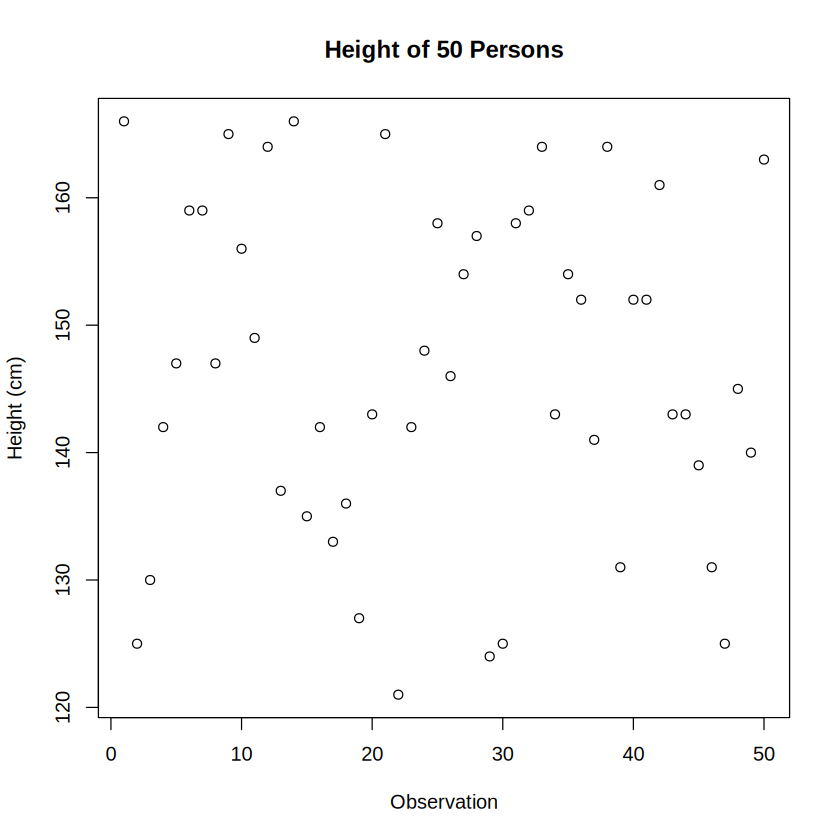

In [21]:
# Scatter/point plot of the height vector
plot(
  height,
  main = "Height of 50 Persons",
  xlab = "Observation",
  ylab = "Height (cm)"
)


## 8. Bar Plots

The notes explain that bar plots visualize absolute or relative frequencies of categorical variables and demonstrate `barplot(table(x))` and `barplot(table(x)/length(x))`. fileciteturn0file0L854-L872

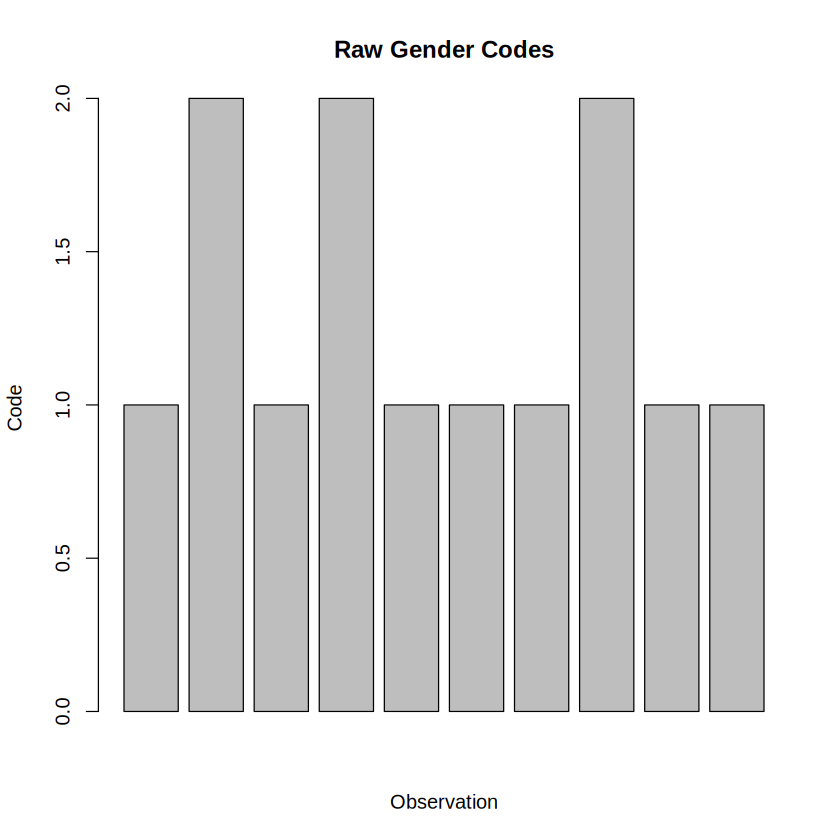

In [22]:
# Direct barplot of the raw gender codes
barplot(
  gender,
  main = "Raw Gender Codes",
  xlab = "Observation",
  ylab = "Code"
)


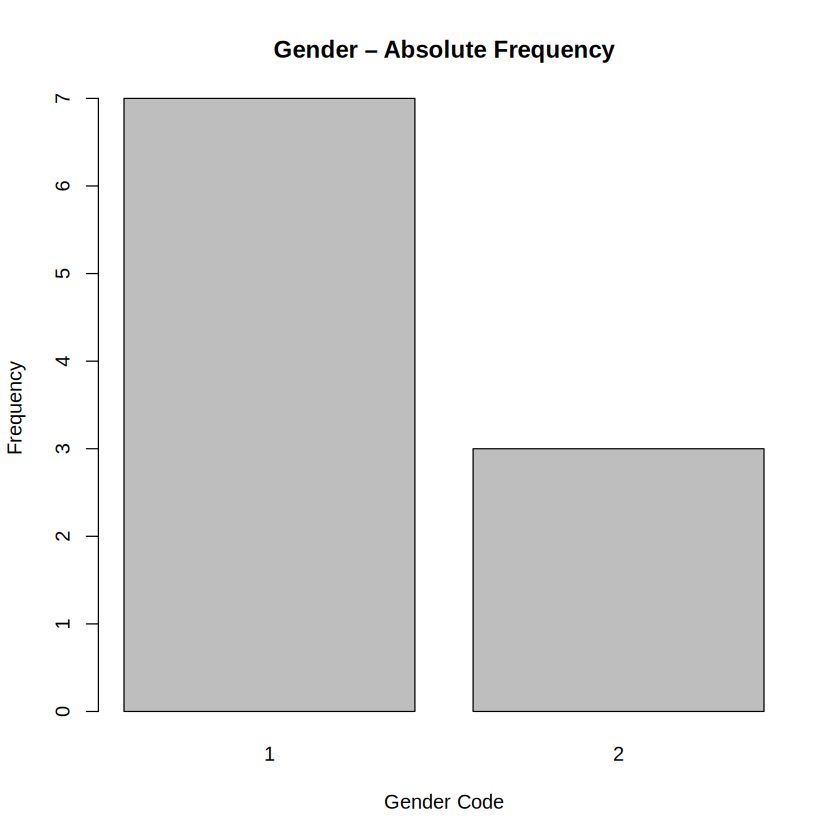

In [23]:
# Bar plot of absolute frequencies
barplot(
  table(gender),
  main = "Gender – Absolute Frequency",
  xlab = "Gender Code",
  ylab = "Frequency"
)


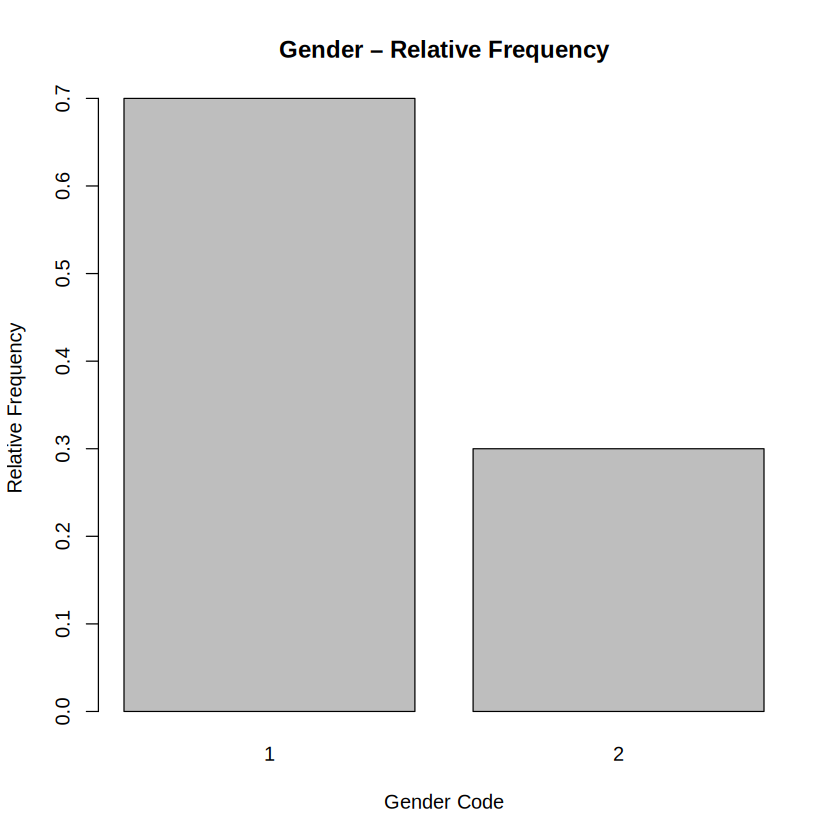

In [24]:
# Bar plot of relative frequencies
barplot(
  table(gender) / length(gender),
  main = "Gender – Relative Frequency",
  xlab = "Gender Code",
  ylab = "Relative Frequency"
)


### 8.1 Pizza-delivery bar plots

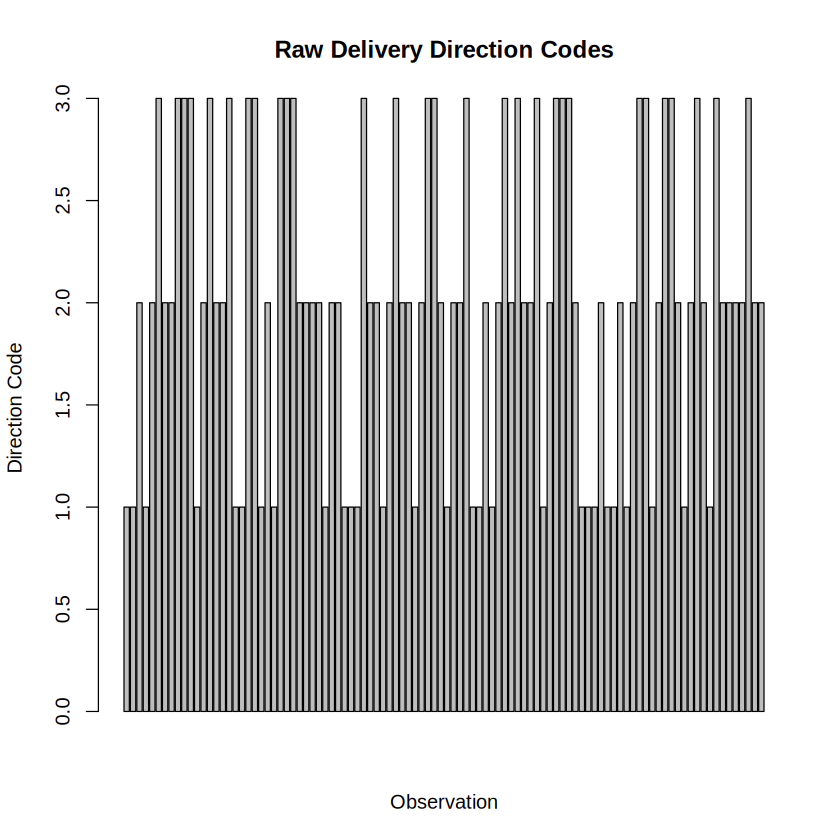

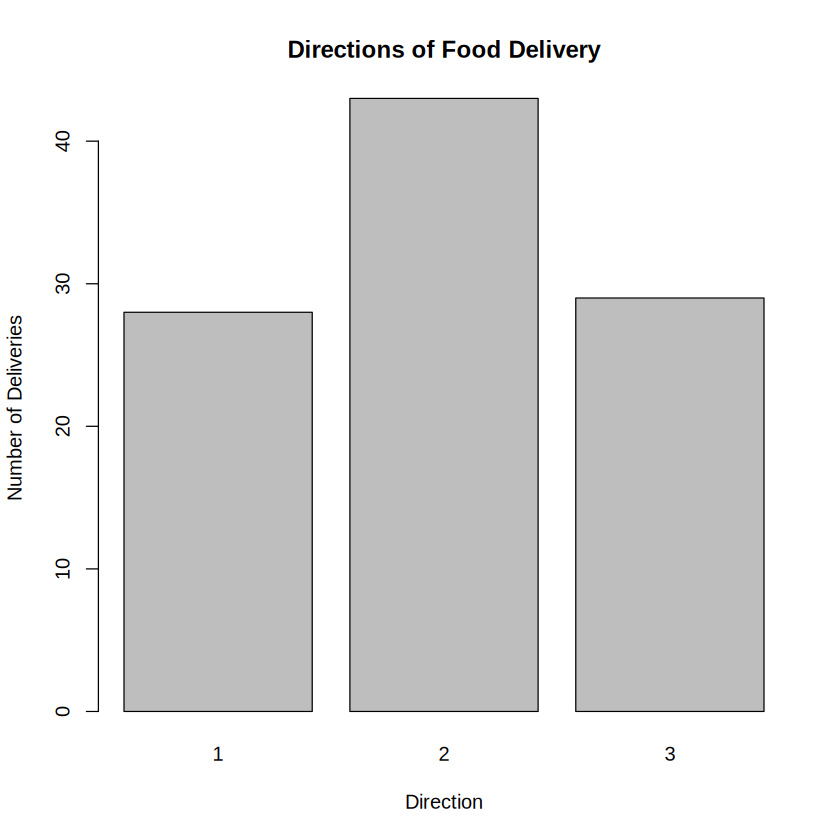

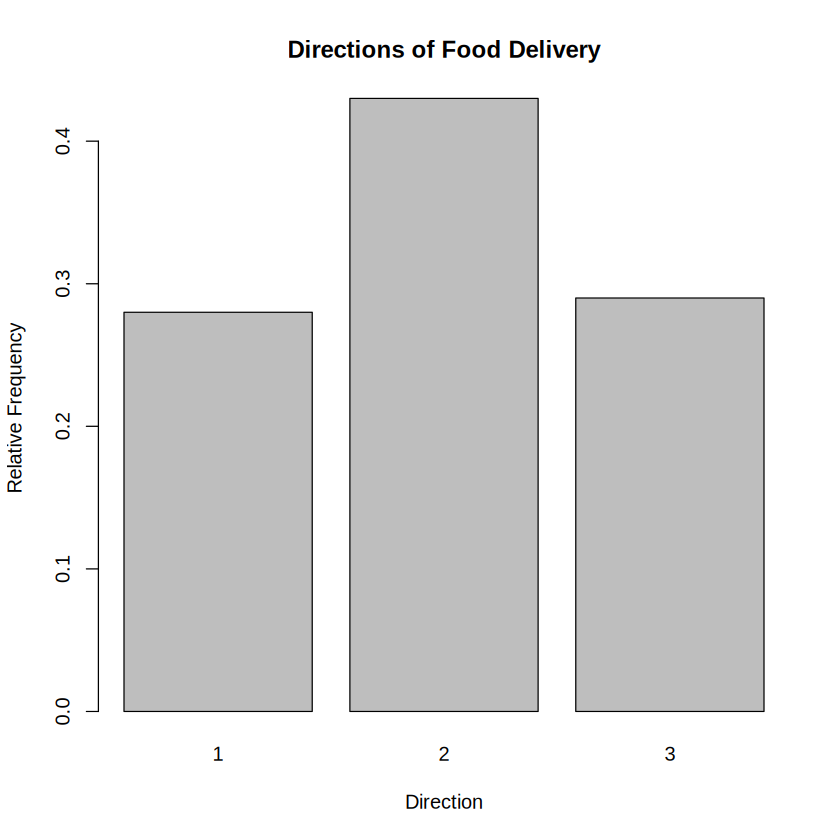

In [25]:
# Raw vector
barplot(
  direction,
  main = "Raw Delivery Direction Codes",
  xlab = "Observation",
  ylab = "Direction Code"
)

# Absolute frequency
barplot(
  table(direction),
  main = "Directions of Food Delivery",
  xlab = "Direction",
  ylab = "Number of Deliveries"
)

# Relative frequency
barplot(
  table(direction) / length(direction),
  main = "Directions of Food Delivery",
  xlab = "Direction",
  ylab = "Relative Frequency"
)


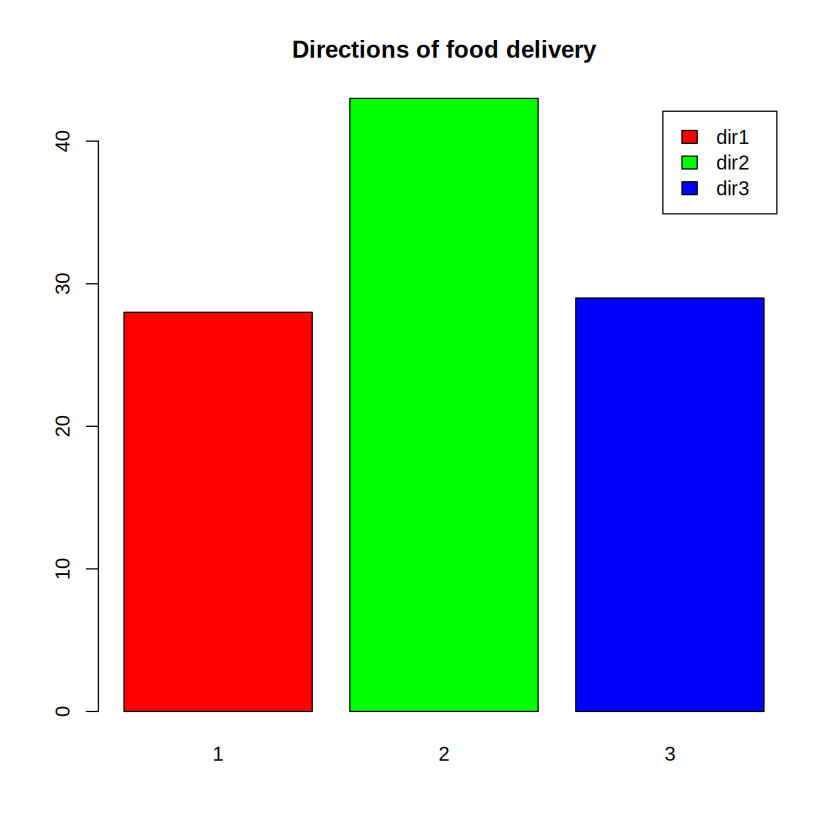

In [26]:
# Customized bar plot: colour, title and legend
barplot(
  table(direction),
  col = c("red", "green", "blue"),
  main = "Directions of food delivery",
  legend.text = c("dir1", "dir2", "dir3")
)


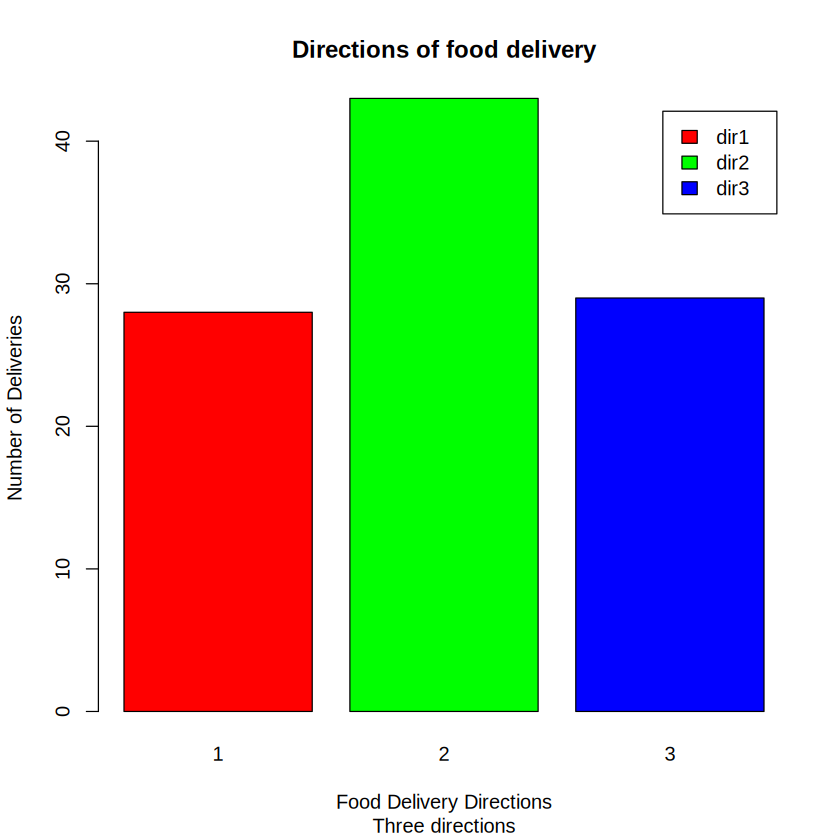

In [27]:
# Customized bar plot with subtitle and axis labels
barplot(
  table(direction),
  col = c("red", "green", "blue"),
  main = "Directions of food delivery",
  legend.text = c("dir1", "dir2", "dir3"),
  sub = "Three directions",
  xlab = "Food Delivery Directions",
  ylab = "Number of Deliveries"
)


## 9. Quick Practice / Verification

Run the cells below after completing the notebook to verify the main outputs.

In [28]:
cat("Number of painters:", nrow(painters), "\n")
cat("Number of variables:", ncol(painters), "\n")
cat("Gender counts:\n")
print(table(gender))
cat("\nGender proportions:\n")
print(prop.table(table(gender)))
cat("\nMarks quartiles:\n")
print(quantile(marks))
cat("\nDelivery direction counts:\n")
print(table(direction))
cat("\nDelivery direction proportions:\n")
print(prop.table(table(direction)))


Number of painters: 54 
Number of variables: 5 
Gender counts:
gender
1 2 
7 3 

Gender proportions:
gender
  1   2 
0.7 0.3 

Marks quartiles:
  0%  25%  50%  75% 100% 
29.0 46.5 63.0 79.5 96.0 

Delivery direction counts:
direction
 1  2  3 
28 43 29 

Delivery direction proportions:
direction
   1    2    3 
0.28 0.43 0.29 


## 10. Summary

### Functions implemented
- Data frames: `summary()`, `attach()`, `detach()`, `subset()`, `[ ]`, `split()`, `is.data.frame()`
- Excel import: `read_excel()`
- Other data formats: `read.spss()`, `readHTMLTable()`, `read.octave()`, `read.systat()`, `read.xport()`, `read.dta()`
- Data writing: `write()`, `write.csv()`, `write.table()`
- Frequencies: `table()`, relative frequency with `table()/length()`
- Partition values: `quantile()`
- Graphics: `plot()`, `barplot()`
- Bar plot customization: `col`, `main`, `legend.text`, `sub`, `xlab`, `ylab`

The notebook also creates a small Excel workbook inside the Colab runtime so the Excel-reading examples can be executed immediately.
